In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
def generate_numbers(n):
    return np.random.uniform(0, 1, n).astype(np.float32)

def relative_error(measured, exact):
    return abs(measured - exact) / exact

def sum_a(numbers):
    total = np.float64(0.0)
    for x in numbers:
        total += np.float64(x)
    return total

def sum_b(numbers):
    total = np.float32(0.0)
    for x in numbers:
        total = np.float32(total + x)
    return total

def sum_c(numbers):
    total = np.float32(0.0)
    err = np.float32(0.0)
    for x in numbers:
        y = np.float32(x - err)
        temp = np.float32(total + y)
        err = np.float32(np.float32(temp - total) - y)
        total = temp
    return total

def sum_d(numbers):
    sorted_nums = np.sort(np.abs(numbers))
    total = np.float32(0.0)
    for x in sorted_nums:
        total = np.float32(total + x)
    return total

def sum_e(numbers):
    sorted_nums = np.sort(np.abs(numbers))[::-1]
    total = np.float32(0.0)
    for x in sorted_nums:
        total = np.float32(total + x)
    return total

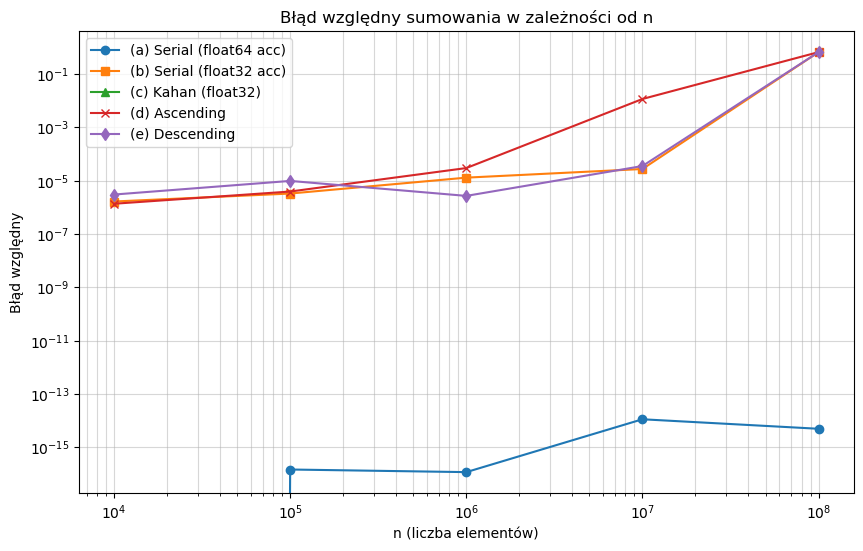

In [3]:
ks = np.arange(4, 9)
ns = 10**ks

errors = { "a": [], "b": [], "c": [], "d": [], "e": [] }

for n in ns:
    data = generate_numbers(n)
    exact_sum = math.fsum(data)
    
    errors["a"].append(relative_error(sum_a(data), exact_sum))
    errors["b"].append(relative_error(sum_b(data), exact_sum))
    errors["c"].append(relative_error(sum_c(data), exact_sum))
    errors["d"].append(relative_error(sum_d(data), exact_sum))
    errors["e"].append(relative_error(sum_e(data), exact_sum))

plt.figure(figsize=(10, 6))
plt.loglog(ns, errors["a"], label='(a) Serial (float64 acc)', marker='o')
plt.loglog(ns, errors["b"], label='(b) Serial (float32 acc)', marker='s')
plt.loglog(ns, errors["c"], label='(c) Kahan (float32)', marker='^')
plt.loglog(ns, errors["d"], label='(d) Ascending', marker='x')
plt.loglog(ns, errors["e"], label='(e) Descending', marker='d')

plt.title('Błąd względny sumowania w zależności od n')
plt.xlabel('n (liczba elementów)')
plt.ylabel('Błąd względny')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()